# Phase 3, Session 3.1: Conv-TasNet Encoder 🎵

Before we touch a single line of Phase 3 code, let me ask you something to activate your intuition.

**Think about this:** You have a raw audio waveform — just a long sequence of numbers like `[0.02, 0.15, -0.08, 0.31, ...]`. If you were designing a system to *separate* two mixed voices, what's the first thing you'd want to do with that raw signal before any separation happens? Take 30 seconds and think about it before reading on.

---

## Theory: The Conv-TasNet Encoder as Learnable Basis Functions

### The big idea

Classical signal processing decomposes signals using *fixed* mathematical functions — Fourier analysis uses sine waves, wavelet analysis uses pre-defined wavelets. These are chosen by humans based on theory.

Conv-TasNet asks a different question: **what if we let the network *learn* the best way to decompose audio for separation?**

The encoder is a 1D convolutional layer whose filters become the "basis functions" — the atoms of a learned dictionary for representing audio. Instead of "decompose into sine waves," it's "decompose into whatever 512 patterns best help you separate speakers."

### What the encoder does

The encoder transforms a raw waveform into a 2D "representation" — a kind of learned spectrogram — where the network can more easily learn to separate speakers.

Here's the transformation:

```
Input:  x  →  shape: (batch, 1, T)
                      ↑       ↑
                   1 channel  T audio samples

Output: H  →  shape: (batch, N, L)
                      ↑       ↑
                   N filters  L frames
```

Where:
- `T` = number of audio samples (e.g. 32,000 for 2 seconds at 16kHz)
- `N` = number of encoder filters (e.g. 512 — each is a "basis function")
- `L` = number of output frames = roughly `T / stride`

Let me show you what's actually happening with concrete numbers.

**Example encoder computation (one filter, one frame):**

Say your encoder has kernel size `L=16` and stride `stride=8`.

```
Audio chunk [0.02, 0.15, -0.08, 0.31, 0.07, -0.12, 0.22, 0.04,
             0.18, -0.03, 0.09, 0.25, -0.16, 0.11, 0.06, -0.09]
                    ↑ 16 samples = 1ms at 16kHz

Filter weights [0.1, -0.3, 0.2, 0.5, ...]   ← LEARNED by gradient descent

Dot product = 0.02×0.1 + 0.15×(-0.3) + (-0.08)×0.2 + ...
            = 0.002 - 0.045 - 0.016 + ...
            = some scalar value

Then apply ReLU → max(0, scalar)
```

This gives you *one* value for *one* filter at *one* time position. The encoder runs all `N=512` filters across all `L` positions simultaneously — that's the 1D convolution.

The key insight: **after training, each of the 512 filters learns to detect a specific acoustic pattern** — one might respond to voiced fricatives, another to voiced vowels, another to a specific pitch range. The network discovers these patterns on its own.

Here's what the encoder looks like in the overall Conv-TasNet pipeline:

The encoder is just the first step. Think of it as: raw waveform → learned representation → (separator will work here) → decoder → separated waveform.

![Encoder Overview](assest/conv_tasnet_encoder_overview.svg)


### Why not just use STFT?

You might be thinking: "We already know how to decompose audio — STFT gives us frequency content at each time step. Why invent a new decomposition?"

Great question. The Short-Time Fourier Transform uses *fixed* sine/cosine basis functions. They're mathematically elegant, but they're not *optimized for separating speakers*. The encoder's learned filters can discover patterns that are much more discriminative for this specific task — patterns that might not have a clean frequency interpretation but that make speaker separation dramatically easier.

Think of it like this: STFT is a general-purpose microscope. The Conv-TasNet encoder is a microscope lens **ground specifically to see the features that distinguish different speakers**.

### The paper's exact specification

From the paper (the EEND-SS architecture we're building toward):

> "ConvEnc(·) consists of a 1-D convolution layer followed by a ReLU."

And from the experimental configuration section:
> "For the encoder and decoder, we set the kernel size to **16** and stride to **8**. The number of encoder filters N = **512**."

This is the encoder you're about to build. Small kernel (16 samples = 1ms at 16kHz), stride half the kernel (50% overlap between frames), 512 filters giving a rich 512-dimensional representation at each time step.

---

## TODO 1: Implement the Conv-TasNet Encoder

**Goal:** Build an `Encoder` class that converts a raw waveform into a learned 2D representation.

**Requirements:**
- Takes a 1D audio tensor of shape `(batch, 1, num_samples)` as input
- Applies a 1D convolution with configurable `num_filters`, `kernel_size`, and `stride`
- Applies ReLU non-linearity after the convolution
- Outputs a tensor of shape `(batch, num_filters, num_frames)`
- Must be an `nn.Module` subclass with proper `__init__` and `forward`
- Default parameters should match the paper: `num_filters=512, kernel_size=16, stride=8`

**Architecture in plain English:**
```
Input: (batch, 1, T)
  → nn.Conv1d(in_channels=1, out_channels=num_filters, ...)
  → ReLU activation
Output: (batch, num_filters, L)
```

**Hints:**
- The only PyTorch class you need is `nn.Conv1d` and a ReLU activation
- Think about what `in_channels` should be for audio (it's simpler than you think)
- The `stride` parameter in `nn.Conv1d` controls how many samples you skip between each convolution window
- `bias=False` is conventional for this encoder (the ReLU handles any necessary shifts)
- Frame count formula: `L = (T - kernel_size) / stride + 1` — verify your output matches this

**Expected shapes with concrete numbers:**

```python
encoder = Encoder(num_filters=512, kernel_size=16, stride=8)
x = torch.randn(4, 1, 32000)   # batch=4, mono, 2 seconds at 16kHz

output = encoder(x)
# Expected shape: (4, 512, ???)
# Calculate: L = (32000 - 16) / 8 + 1 = ???
# What is L?
```

Work out `L` before you write any code. If your output doesn't match this shape, something is wrong.

**After it works — experiments:**
1. Try `num_filters=8` and visualize the 8 learned filters as waveforms after random initialization. What do they look like before any training?
2. Try kernel sizes `[4, 16, 64, 256]`. How does this change the output `L`? What's the trade-off in temporal resolution vs. filter size?
3. Pass the *same* audio chunk through twice. Is the output identical? (It should be — there's no randomness in a trained encoder forward pass.)

**Where to put this:** Create `src/models/conv_tasnet.py` — this is where the full Conv-TasNet will eventually live.

---

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn

import matplotlib.pyplot as plt
import math 

from pathlib import Path
import os
import sys

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent
sys.path.insert(0, str(project_root))

from src.data.loaders import get_dataloaders


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

✅ Using Apple Silicon GPU
PyTorch version: 2.1.0
Device: mps


In [3]:
batch_size = 4

train_loader, val_loader, test_loader = get_dataloaders(
    train_manifest="../../data/processed/test/test_manifest.json",
    val_manifest="../../data/processed/train/train_manifest.json",
    test_manifest="../../data/processed/val/val_manifest.json",
    batch_size=batch_size,
)

In [4]:
class Encoder(nn.Module):
    def __init__(
            self, 
            num_filters=512, 
            kernel_size=16, 
            stride=8,
            device='cpu'
    ):
        super().__init__()
        
        self.conv1d = nn.Conv1d(
            in_channels=1, 
            out_channels=num_filters, 
            kernel_size=kernel_size,
            stride=stride,
            bias=False,
            device=device
            )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.unsqueeze(1)
        print(x.shape)
        x = self.conv1d(x)
        x = self.relu(x)
        return x

In [5]:
def plot_all_learned_kernels(model):
    # 1. Extract weights
    kernels = model.conv1d.weight.detach().cpu().numpy()
    num_kernels = kernels.shape[0]
    
    # 2. Calculate grid dimensions
    cols = 2  # Keep it at 2 columns like your image for readability
    rows = math.ceil(num_kernels / cols)
    
    # 3. Dynamic figure height based on number of rows
    plt.figure(figsize=(15, rows * 3)) 
    plt.suptitle("Visualizing Learned Kernels (Speech Encoder)", fontsize=16)

    for i in range(num_kernels):
        kernel_values = kernels[i, 0, :]
        
        plt.subplot(rows, cols, i + 1)
        plt.plot(kernel_values, color='teal', linewidth=1)
        
        # --- The missing pieces ---
        plt.title(f"Kernel {i+1}")
        plt.grid(True, which='both', linestyle='--', alpha=0.5) # Add the grid
        plt.xlabel("Samples")
        plt.ylabel("Weight")
        # --------------------------
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [6]:
num_filters=512
kernel_size=16
stride=8

batch = next(iter(train_loader))

audio_batch = batch["mixture"].to(device)
print(audio_batch.shape)

encoder = Encoder(num_filters=num_filters, kernel_size=kernel_size, stride=stride, device=device)

output = encoder(audio_batch)
print(output.shape)

L = int((audio_batch.shape[1] - kernel_size)/stride + 1)

assert output.shape == (batch_size, num_filters, L), f"expected shape is ({batch_size, num_filters, L}) but got {output.shape}"

torch.Size([4, 480000])
torch.Size([4, 1, 480000])
torch.Size([4, 512, 59999])


torch.Size([4, 480000])
torch.Size([4, 1, 480000])
torch.Size([4, 8, 59999])


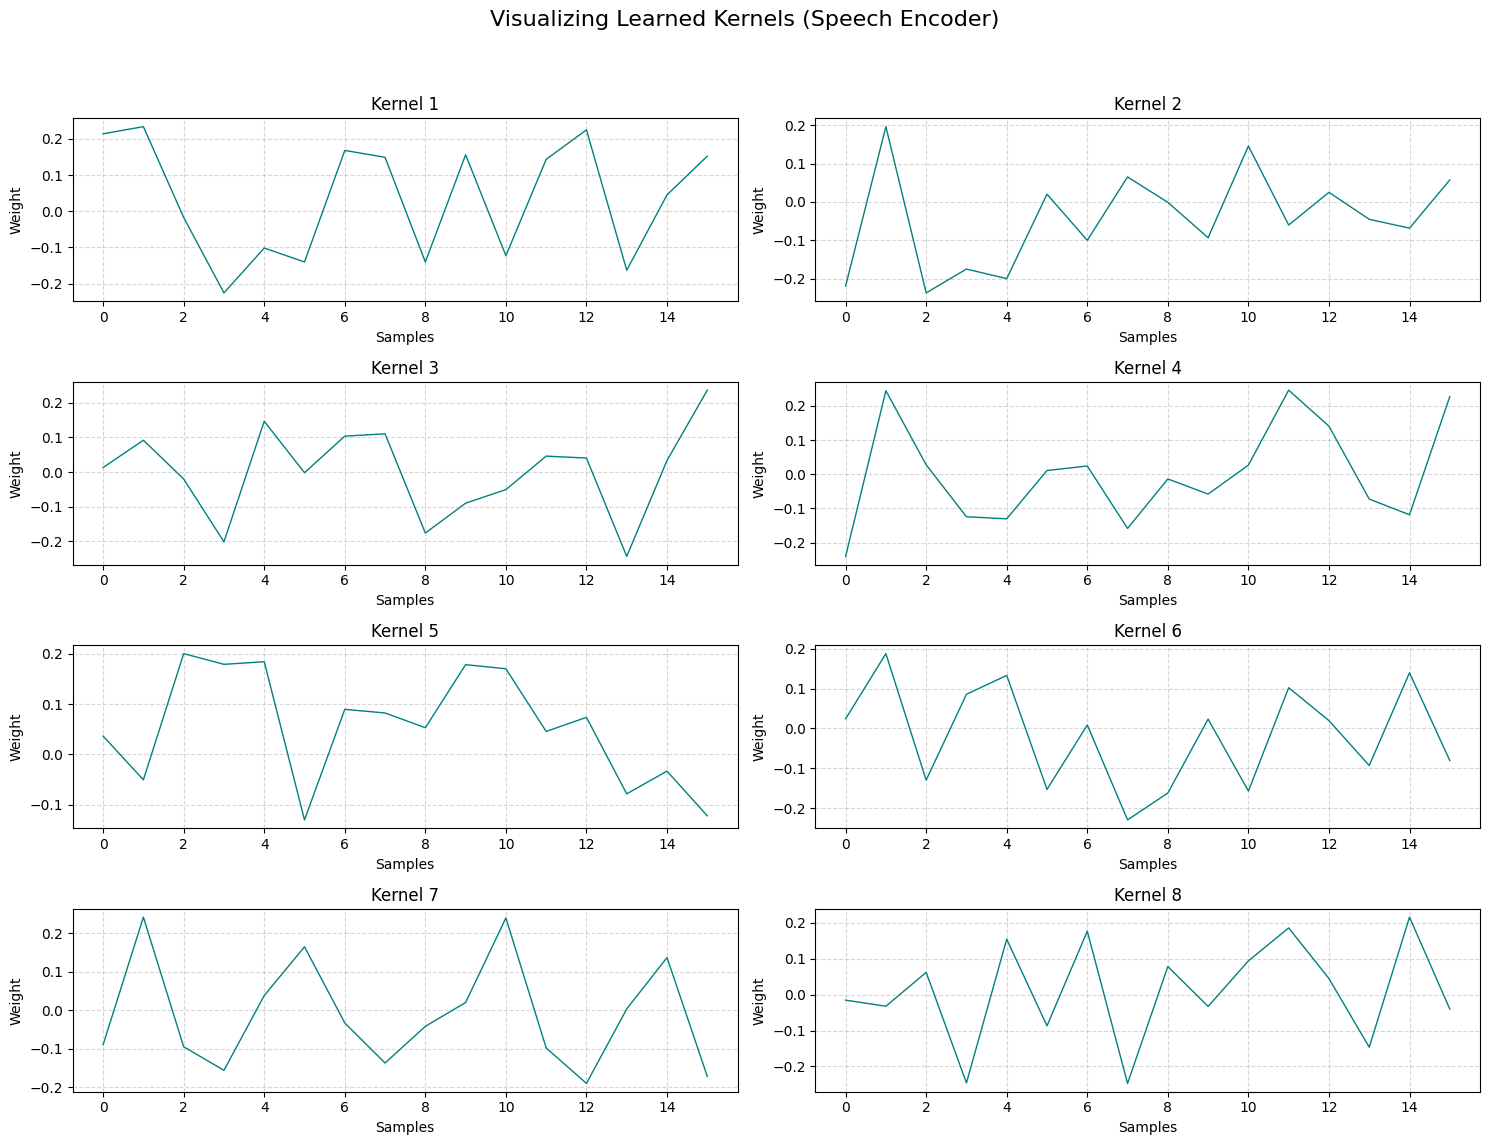

In [7]:
num_filters=8
kernel_size=16
stride=8

batch = next(iter(train_loader))

audio_batch = batch["mixture"].to(device)
print(audio_batch.shape)

encoder = Encoder(num_filters=num_filters, kernel_size=kernel_size, stride=stride, device=device)

output = encoder(audio_batch)
print(output.shape)

L = int((audio_batch.shape[1] - kernel_size)/stride + 1)

assert output.shape == (batch_size, num_filters, L), f"expected shape is ({batch_size, num_filters, L}) but got {output.shape}"
plot_all_learned_kernels(encoder)

In [11]:
num_filters=8
kernel_size=16
stride=8

batch = next(iter(train_loader))

audio_batch = batch["mixture"].to(device)

encoder = Encoder(num_filters=num_filters, kernel_size=kernel_size, stride=stride, device=device)

output1 = encoder(audio_batch)
output2 = encoder(audio_batch)
L = int((audio_batch.shape[1] - kernel_size)/stride + 1)

assert torch.allclose(output1, output2), "output 1 and 2 are not close in value"
print("both tensors are close in values")


torch.Size([4, 1, 480000])
torch.Size([4, 1, 480000])
both tensors are close in values
